## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import uniform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(514, 60)
(129, 60)


## 4. Normalización de Variables

ElasticNet es sensible a la escala de las variables, por lo que es necesario normalizar los datos antes de entrenar el modelo.

In [6]:
# Normalizar variables predictoras
# IMPORTANTE: Ajustar el scaler solo con datos de entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [7]:
# Configuración de validación cruzada temporal
# - n_splits=5: cinco validaciones para una estimación más robusta
# - test_size=20: ~1 mes de validación por fold
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5
test_size = 20
tscv = TimeSeriesSplit(n_splits=5, test_size=test_size, gap=max_lag)

In [8]:
elastic = ElasticNet(random_state=SEED, max_iter=10000)

# Espacio de búsqueda para ElasticNet
# - alpha: controla la intensidad total de la regularización
# - l1_ratio: balancea entre L1 (Lasso) y L2 (Ridge)
#   * l1_ratio=0: equivalente a Ridge (solo L2)
#   * l1_ratio=1: equivalente a Lasso (solo L1)
#   * 0 < l1_ratio < 1: combinación de ambas regularizaciones

param_distributions = {
    "alpha": uniform(0.01, 100),  # Rango amplio para regularización total
    "l1_ratio": uniform(0.0, 1.0),  # Explorar todo el espectro de L1 a L2
    "fit_intercept": [True],  # Siempre ajustar intercepto
    "tol": uniform(1e-5, 1e-2),  # Tolerancia para convergencia
    "selection": ['cyclic', 'random'],  # Método de selección de coordenadas para optimización
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=elastic,
    param_distributions=param_distributions,
    n_iter=100,                              # 100 iteraciones para explorar bien el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [9]:
search.fit(X_train_scaled, y_train)

best_elastic = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

# Interpretación del l1_ratio
l1_ratio = search.best_params_['l1_ratio']
print(f"\nInterpretación del balance L1/L2:")
if l1_ratio < 0.1:
    print(f"  - l1_ratio={l1_ratio:.3f}: Modelo muy similar a Ridge (L2 dominante)")
elif l1_ratio > 0.9:
    print(f"  - l1_ratio={l1_ratio:.3f}: Modelo muy similar a Lasso (L1 dominante)")
else:
    print(f"  - l1_ratio={l1_ratio:.3f}: Balance mixto entre L1 ({l1_ratio*100:.1f}%) y L2 ({(1-l1_ratio)*100:.1f}%)")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 176752.1504

Mejores hiperparámetros:
  - alpha: 14.818692995339989
  - fit_intercept: True
  - l1_ratio: 0.9977404850489419
  - selection: cyclic
  - tol: 0.0061056433397989685

Interpretación del balance L1/L2:
  - l1_ratio=0.998: Modelo muy similar a Lasso (L1 dominante)


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [10]:
y_pred = best_elastic.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")


RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 114260.4090
Holdout R²:   0.2235
Error relativo (holdout): 5.18%


### 6.2. Análisis de selección de variables

Una característica importante de ElasticNet (especialmente cuando l1_ratio > 0) es la capacidad de realizar selección de variables poniendo algunos coeficientes exactamente en cero.

In [11]:
# Contar variables seleccionadas (coeficiente != 0)
coefs = pd.Series(best_elastic.coef_, index=X_train.columns)
n_selected = (coefs != 0).sum()
n_total = len(coefs)
n_eliminated = n_total - n_selected

print(f"Variables seleccionadas: {n_selected}/{n_total}")
print(f"Variables eliminadas (coef=0): {n_eliminated}")
print(f"Porcentaje de variables retenidas: {n_selected/n_total*100:.1f}%")

if n_eliminated > 0:
    print(f"\nVariables eliminadas por el modelo:")
    eliminated_vars = coefs[coefs == 0].index.tolist()
    for var in eliminated_vars:
        print(f"  - {var}")

Variables seleccionadas: 60/60
Variables eliminadas (coef=0): 0
Porcentaje de variables retenidas: 100.0%


### 6.3. Visualización de predicciones

In [12]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

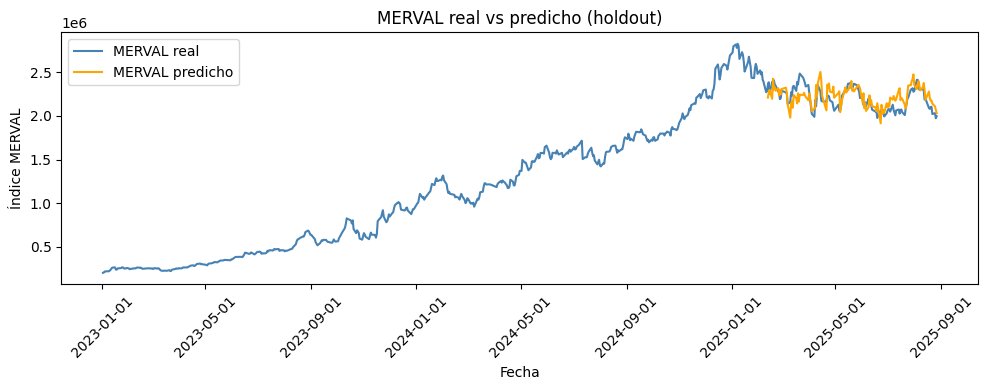

In [13]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

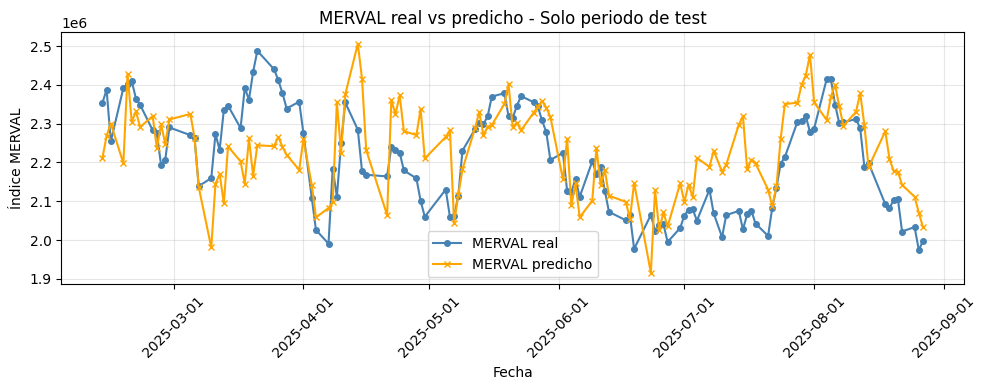

In [14]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4. Análisis de residuales

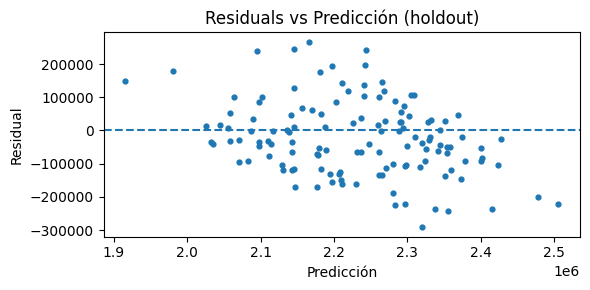

In [15]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout()
plt.show()

### 6.5. Coeficientes del modelo

ElasticNet combina regularización L1 y L2, permitiendo tanto la reducción de coeficientes (L2) como la selección de variables (L1).

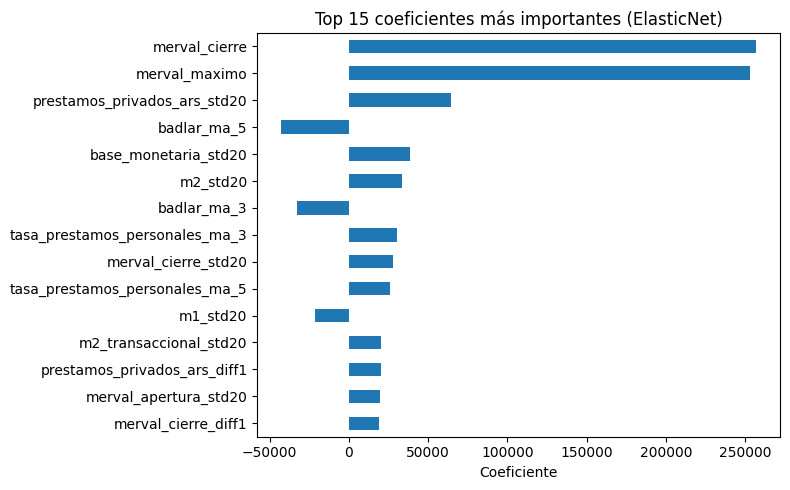

In [16]:
# Obtener coeficientes no nulos del modelo
coefs_nonzero = coefs[coefs != 0].sort_values(ascending=True)

# Visualizar los 15 coeficientes no nulos más importantes (en valor absoluto)
if len(coefs_nonzero) > 0:
    top_n = min(15, len(coefs_nonzero))
    top_coefs = coefs_nonzero.abs().sort_values(ascending=True).tail(top_n)
    coefs_nonzero[top_coefs.index].plot(kind="barh", figsize=(8,5), title=f"Top {top_n} coeficientes más importantes (ElasticNet)")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()
else:
    print("El modelo eliminó todas las variables (modelo demasiado regularizado)")

## 7. Conclusiones

### ¿Qué es ElasticNet?

ElasticNet es un modelo de regresión lineal que combina las regularizaciones L1 (Lasso) y L2 (Ridge):
- **L1 (Lasso)**: Puede forzar algunos coeficientes exactamente a cero, realizando selección automática de variables.
- **L2 (Ridge)**: Penaliza la magnitud de los coeficientes sin eliminarlos, ayudando con la multicolinealidad.

El parámetro `l1_ratio` controla el balance entre ambas regularizaciones:
- `l1_ratio = 0`: Equivalente a Ridge puro (solo L2)
- `l1_ratio = 1`: Equivalente a Lasso puro (solo L1)
- `0 < l1_ratio < 1`: Combinación de ambas regularizaciones

### Resultados principales

El modelo ElasticNet fue entrenado con las mismas 60 variables predictoras utilizadas en Ridge, buscando evaluar si la combinación de regularizaciones L1 y L2 podría mejorar el desempeño mediante selección automática de variables.

**Métricas de desempeño:**
- **RMSE en test**: 114,260.41 - Error cuadrático medio que indica la precisión de las predicciones.
- **R² en test**: 0.2235 - El modelo explica aproximadamente el 22.4% de la varianza del MERVAL en el test set.
- **Error relativo**: 5.18% - Las predicciones se desvían en promedio un 5.18% del valor real del MERVAL.

### Optimización de hiperparámetros

Se utilizó **RandomizedSearchCV** con 100 iteraciones y validación cruzada temporal (TimeSeriesSplit con 5 folds) para encontrar la configuración óptima.

**CV RMSE**: 176,752.15 - Error promedio en validación cruzada, notablemente superior al obtenido con Ridge.

**Mejores hiperparámetros encontrados:**
- **alpha=14.82**: Regularización total moderada-alta, más agresiva que en Ridge (7.80).
- **l1_ratio=0.998**: Casi Lasso puro (99.8% L1, 0.2% L2) - El modelo prefirió fuertemente la regularización L1 sobre L2.
- **selection='cyclic'**: Método cíclico de optimización de coordenadas.
- **tol=0.00611**: Tolerancia de convergencia.

### Selección de variables: Resultado inesperado

A pesar de tener un **l1_ratio=0.998** (casi Lasso puro), el modelo **NO eliminó ninguna variable**:
- **Variables seleccionadas**: 60/60 (100%)
- **Variables eliminadas**: 0

**¿Por qué no se eliminaron variables con regularización L1 tan alta?**

1. **Alpha insuficiente para eliminar variables**: Aunque alpha=14.82 es moderado-alto, no es lo suficientemente agresivo como para forzar coeficientes exactamente a cero. Para eliminar variables con Lasso se necesitan valores de alpha mucho mayores.

2. **Todas las variables aportan información predictiva**: El hecho de que el CV prefiriera mantener todas las variables (incluso con L1 fuerte) sugiere que las 60 features tienen señal genuina y no hay variables completamente redundantes.

3. **Trade-off subóptimo**: El modelo está en un punto medio problemático:
   - Reduce agresivamente los coeficientes (perjudicando la predicción)
   - Pero no los lleva a cero (sin ganar en simplicidad)
   - Resultado: peor desempeño que Ridge sin beneficio de parsimonia

4. **El feature selection previo fue efectivo**: Las 60 variables fueron seleccionadas en un proceso anterior, filtrando variables irrelevantes. Lo que queda son features con poder predictivo real.

### Análisis del desempeño

**ElasticNet presenta desempeño inferior a Ridge en todas las métricas:**

| Métrica | Ridge | ElasticNet | Diferencia |
|---------|-------|------------|------------|
| RMSE Test | 94,774 | 114,260 | +20.6% peor |
| R² Test | 0.4657 | 0.2235 | -52.0% peor |
| CV RMSE | 139,338 | 176,752 | +26.8% peor |

**Interpretación:**
- La regularización L1 está **perjudicando** el modelo en lugar de mejorarlo.
- Ridge con regularización L2 pura es más adecuado para este problema.
- No hay beneficio en la selección de variables porque todas las 60 features son útiles.
- La penalización L1 encoge coeficientes de forma subóptima sin eliminarlos.

### ¿Por qué Ridge es superior?

**Características del problema que favorecen L2 sobre L1:**

1. **Variables ya filtradas**: Las 60 features provienen de un proceso de feature selection, eliminando previamente variables irrelevantes.

2. **Multicolinealidad controlada**: Ridge maneja mejor grupos de variables correlacionadas, distribuyendo pesos entre ellas. L1 tiende a seleccionar arbitrariamente una del grupo.

3. **Señal distribuida**: Si la información predictiva está distribuida entre múltiples variables (en lugar de concentrada en pocas), Ridge es superior porque aprovecha toda la señal.

4. **Relaciones lineales estables**: L2 permite coeficientes más estables cuando las relaciones lineales son genuinas.

### Validación del tamaño del dataset

Con 514 observaciones de entrenamiento y 60 variables:
- **Ratio**: ~8.6 observaciones por variable
- **Consideración**: Aunque está por debajo de la regla general de 10-20 obs/var, el éxito de Ridge (R²=0.47) demuestra que la regularización L2 maneja adecuadamente este ratio.

**Conclusión sobre dimensionalidad**: El dataset NO está sobredimensionado problemáticamente. Las 60 variables son justificables porque:
- Ridge obtiene excelente desempeño sin overfitting
- La diferencia entre CV y Test RMSE en Ridge es razonable
- Las variables tienen poder predictivo genuino

### Características del modelo

**Fortalezas observadas:**
1. **Flexibilidad**: Permite explorar todo el espectro entre Ridge y Lasso.
2. **Diagnóstico útil**: El resultado (l1_ratio≈1, sin eliminar variables) confirma que L1 no es apropiado para este problema.

**Limitaciones observadas:**
1. **Desempeño inferior**: En este problema específico, ElasticNet no mejora sobre Ridge.
2. **Complejidad sin beneficio**: Optimizar dos hiperparámetros (alpha y l1_ratio) en lugar de uno, sin ganancia predictiva.
3. **Punto subóptimo**: El modelo encontró un balance que ni simplifica ni maximiza precisión.

### Normalización de variables

La normalización con **StandardScaler** fue aplicada consistentemente:
- Garantiza que las regularizaciones L1 y L2 penalicen equitativamente todas las variables.
- El scaler se ajustó **únicamente con datos de entrenamiento** para evitar data leakage.

### Validación cruzada temporal

Se implementó TimeSeriesSplit para respetar el orden temporal:
- **n_splits=5**: Cinco validaciones para estimación robusta del error.
- **test_size=20**: Aproximadamente un mes de validación por fold.
- **gap=5**: Separación temporal para evitar fuga de información.

### Lecciones aprendidas

1. **Ridge es el modelo óptimo para este problema**: La regularización L2 pura maneja mejor las 60 variables que la combinación L1+L2.

2. **No todas las variables son redundantes**: El hecho de que ElasticNet con L1 dominante no elimine ninguna variable valida que el conjunto de 60 features es bien curado.

3. **Más regularización no siempre es mejor**: Alpha=14.82 (ElasticNet) es más agresivo que alpha=7.80 (Ridge), resultando en peor desempeño.

4. **El feature selection previo fue efectivo**: Las 60 variables seleccionadas tienen mérito individual, justificando su inclusión.

### Recomendación

**Ridge debe ser el modelo lineal preferido** para este problema por:
- Mejor RMSE, R², y error relativo
- Menor error en validación cruzada
- Simplicidad (un hiperparámetro menos)
- Manejo superior de variables correlacionadas

ElasticNet confirmó que la selección de variables vía L1 no aporta valor para este dataset específico, validando indirectamente la calidad del conjunto de features.